<a href="https://colab.research.google.com/github/dhimasprimaj/heart-attack-classification/blob/memberi-insights/Heart_Attack_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project Heart Attack Classification by PatternSeeker

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


from sklearn.metrics import roc_auc_score, roc_curve, recall_score, precision_score, f1_score, auc, classification_report, accuracy_score, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

import pickle

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

random_state_value = 42

## Import Data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/Pattern-Seeker/heart-attack-classification/refs/heads/main/heart_attack_prediction_dataset.csv')
df

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,1,7.917342,Healthy,1,1,8,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,0,16.558426,Healthy,0,0,8,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,1,3.148438,Average,1,0,5,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,0,3.789950,Unhealthy,1,1,5,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


## EDA

In [ ]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [ ]:
df.isnull().sum()

Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype: int64

In [ ]:
df['Country'].value_counts()

Country
Germany           477
Argentina         471
Brazil            462
United Kingdom    457
Australia         449
Nigeria           448
France            446
Canada            440
China             436
New Zealand       435
Japan             433
Italy             431
Spain             430
Colombia          429
Thailand          428
South Africa      425
Vietnam           425
United States     420
India             412
South Korea       409
Name: count, dtype: int64

In [ ]:
df['Continent'].value_counts()

Continent
Asia             2543
Europe           2241
South America    1362
Australia         884
Africa            873
North America     860
Name: count, dtype: int64

In [ ]:
df['Heart Attack Risk'].value_counts()

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

In [ ]:
df['Heart Attack Risk'].value_counts(normalize=True)*100

Heart Attack Risk
0    64.178934
1    35.821066
Name: proportion, dtype: float64

In [ ]:
df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,0.498345,5.469702,5.993690,158263.181901,28.891446,417.677051,3.489672,7.023508,0.358211
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,0.500026,2.859622,3.466359,80575.190806,6.319181,223.748137,2.282687,1.988473,0.479502
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,0.000000,3.000000,2.998794,88310.000000,23.422985,225.500000,2.000000,5.000000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,0.000000,5.000000,5.933622,157866.000000,28.768999,417.000000,3.000000,7.000000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,1.000000,8.000000,9.019124,227749.000000,34.324594,612.000000,5.000000,9.000000,1.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.000000,1.000000


## Feature Engineering
**Melakukan sedikit *Feature Engineering* dengan mengubah Blood Pressure dengan menjadikannya 2 fitur numerik, dan kemudian hapus kolom Blood Pressure**

In [ ]:
df_copy = df.copy()

In [ ]:
df_copy[['BP-Systolic','BP-Diastolic']] = (df_copy['Blood Pressure'].str.split('/', expand = True)).astype(int)
df_copy.drop(columns = ['Blood Pressure'], inplace = True)

In [ ]:
df_copy

,Patient ID,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,BP-Systolic,BP-Diastolic
0,BMW7812,67,Male,208,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0,158,88
1,CZE1114,21,Male,389,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0,165,93
2,BNI9906,21,Female,324,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0,174,99
3,JLN3497,84,Male,383,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0,163,100
4,GFO8847,66,Male,318,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0,91,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,61,1,1,1,0,1,7.917342,Healthy,1,1,8,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0,94,76
8759,QSV6764,28,Female,120,73,1,0,0,1,0,16.558426,Healthy,0,0,8,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0,157,102
8760,XKA5925,47,Male,250,105,0,1,1,1,1,3.148438,Average,1,0,5,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1,161,75
8761,EPE6801,36,Male,178,60,1,0,1,0,0,3.789950,Unhealthy,1,1,5,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0,119,67


## Univariate Analysis

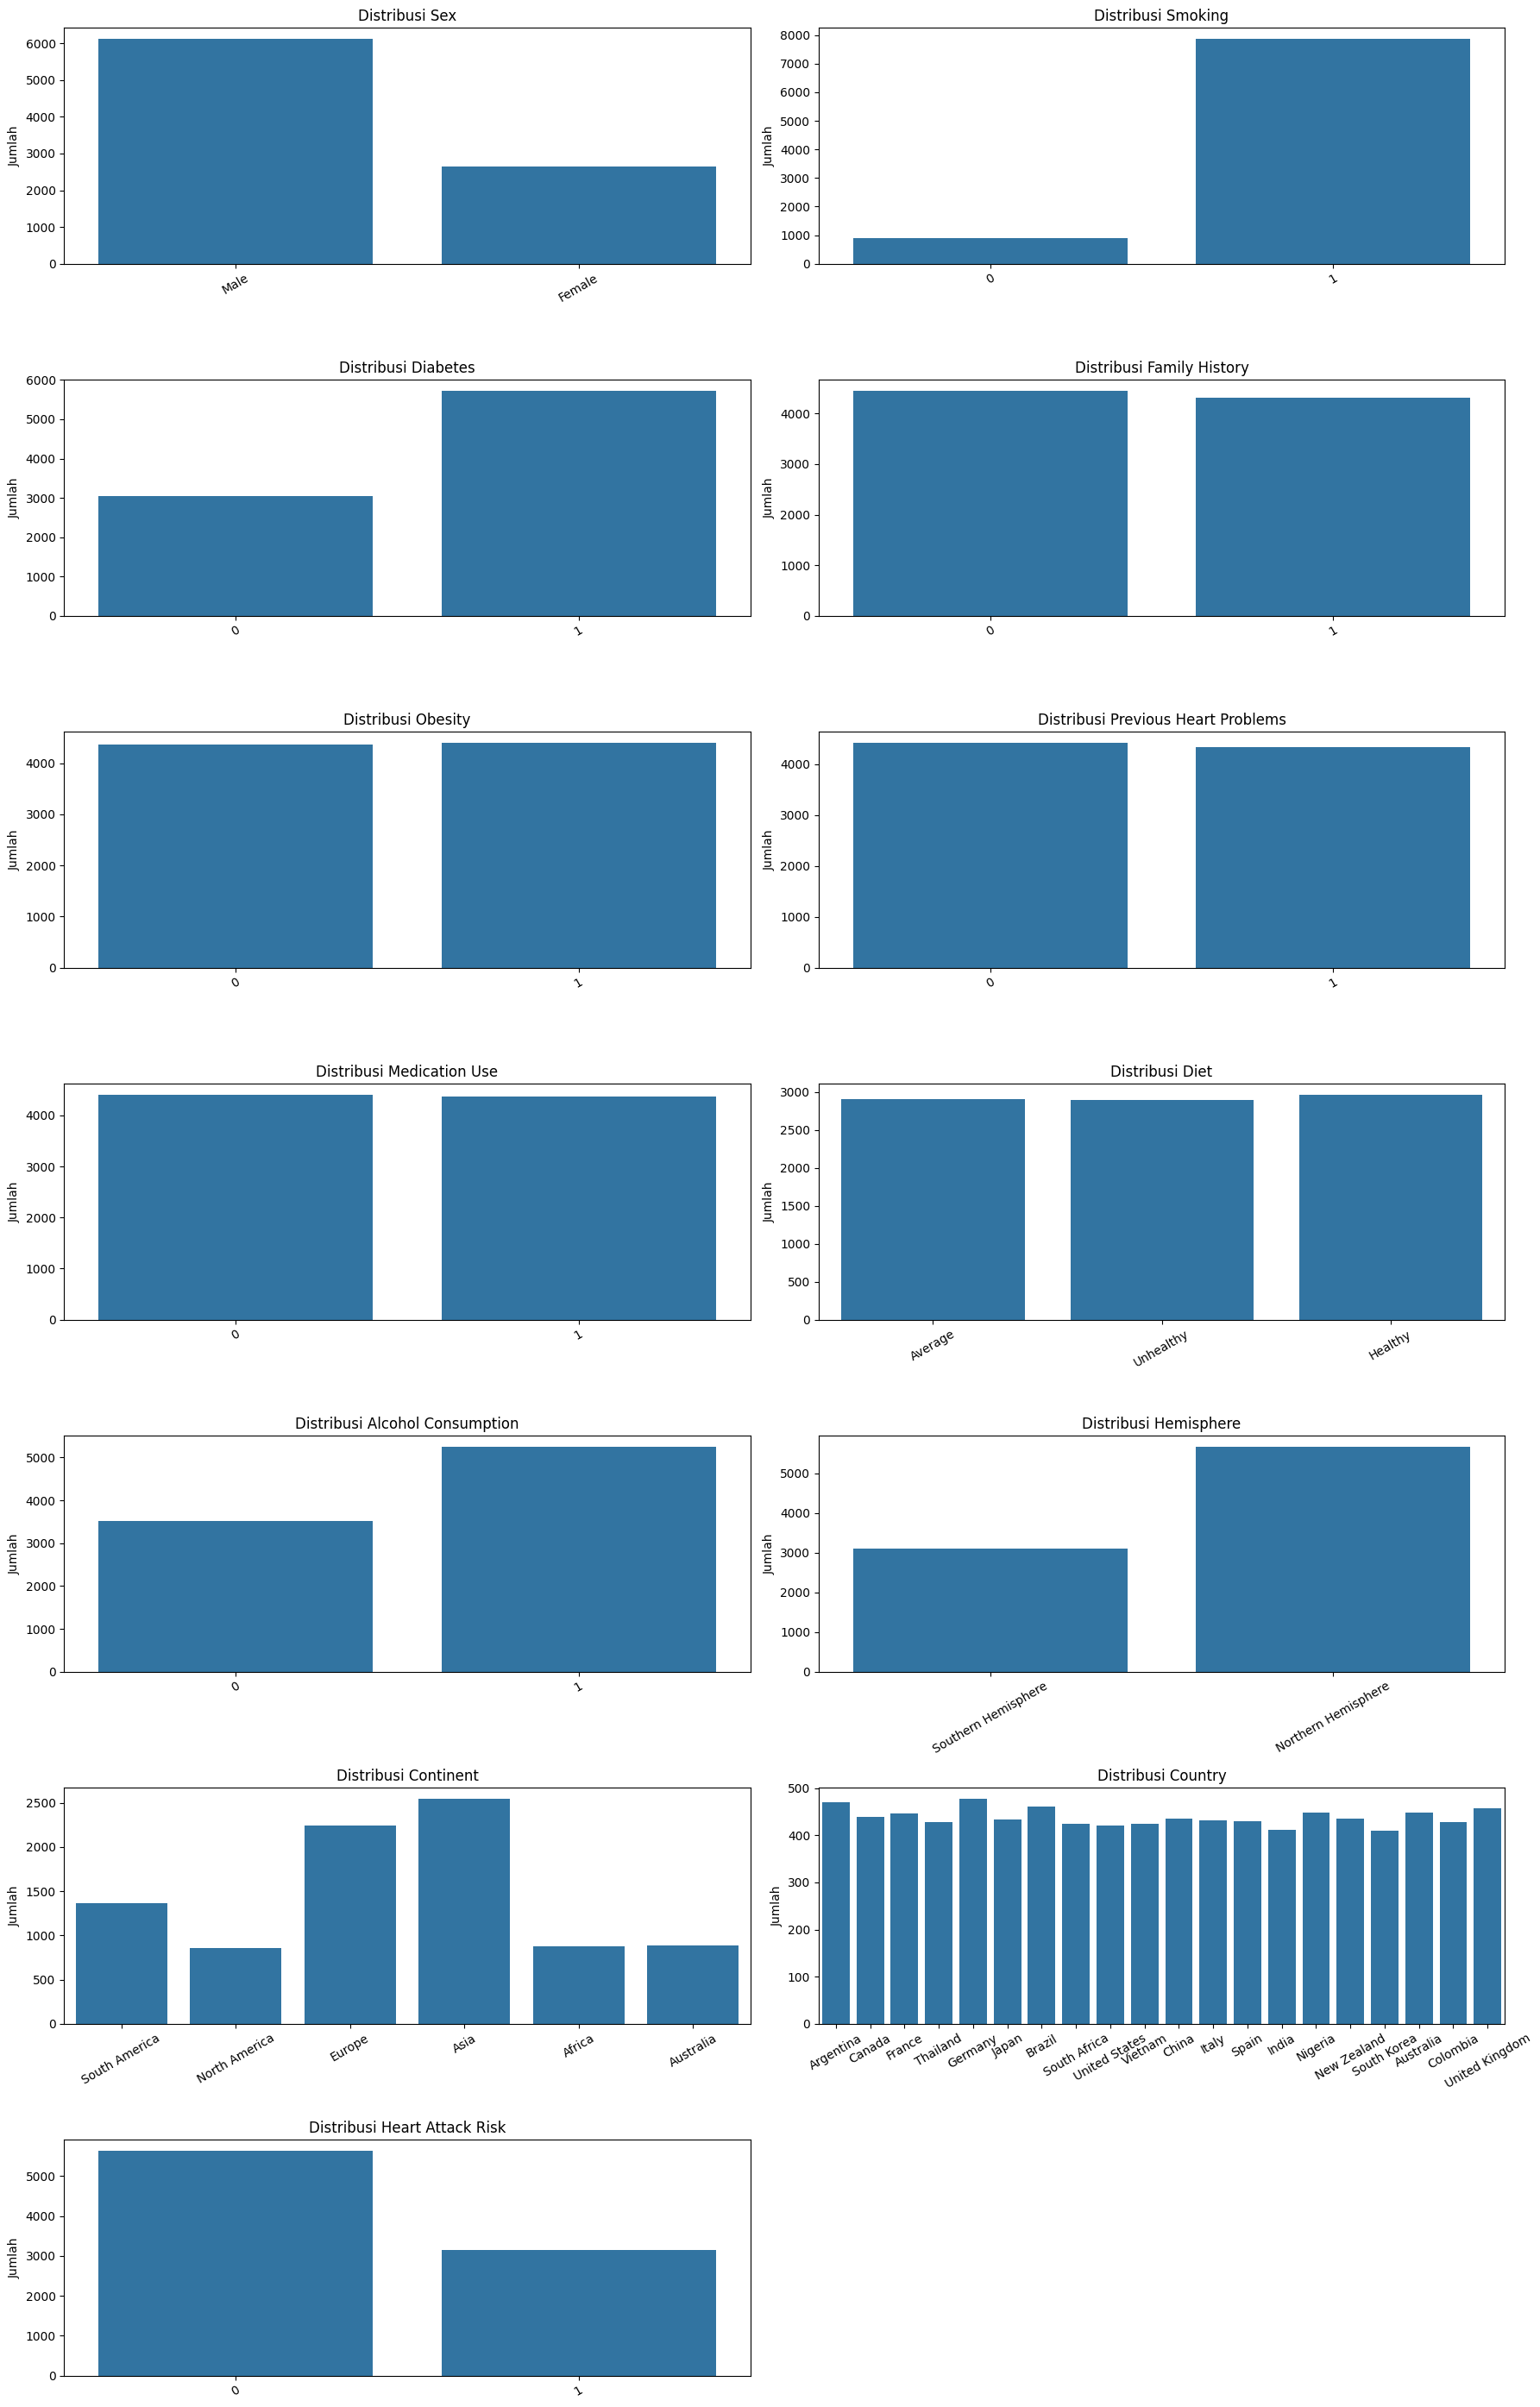

In [ ]:
cat = ['Sex', 'Smoking', 'Diabetes', 'Family History', 'Obesity',
       'Previous Heart Problems', 'Medication Use', 'Diet',
       'Alcohol Consumption', 'Hemisphere', 'Continent', 'Country',
       'Heart Attack Risk']

cols = 2
rows = math.ceil(len(cat) / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(18, rows*4))

axes = axes.flatten()

for i, col in enumerate(cat):
    sns.countplot(x=col, data=df_copy, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. **Profil Risiko Utama (Ketidakseimbangan Data)**
- Heart Attack Risk

Mayoritas individu dalam dataset dikategorikan tidak memiliki risiko serangan jantung (label 0). Jumlahnya hampir dua kali lebih banyak dibandingkan individu yang berisiko (label 1). Hal ini menunjukkan bahwa dataset memiliki ketidakseimbangan kelas (imbalanced data) yang perlu diperhatikan saat membangun model klasifikasi, karena model berpotensi lebih condong memprediksi kelas mayoritas.

- Smoking

Sebagian besar individu dalam dataset tercatat sebagai perokok (label 1). Proporsi ini cukup dominan dibandingkan non-perokok. Kondisi ini menunjukkan bahwa faktor perilaku yang berkaitan dengan risiko kesehatan jantung cukup tinggi dalam populasi sampel, sehingga variabel ini berpotensi menjadi indikator penting dalam analisis risiko.

2. **Demografi dan Geografi**
- Jenis Kelamin (Sex)

Distribusi jenis kelamin menunjukkan bahwa populasi didominasi oleh pria, dengan jumlah lebih dari 6.000 individu, sedangkan wanita berada di bawah 3.000. Perbedaan ini menunjukkan bahwa sampel penelitian lebih banyak merepresentasikan populasi pria dibandingkan wanita.

- Distribusi Wilayah

  - Benua: Sebagian besar data berasal dari Asia dan Eropa, yang menjadi kontributor terbesar dalam dataset.

  - Hemisfer: Mayoritas individu berasal dari belahan bumi utara (Northern Hemisphere).

  - Negara: Jumlah sampel antar negara relatif merata, dengan kisaran sekitar 400–500 individu per negara. Distribusi ini menunjukkan bahwa pengumpulan data dilakukan secara global dengan jumlah yang cukup seimbang di setiap wilayah.

3. **Kondisi Kesehatan dan Gaya Hidup**
- Diabetes

Jumlah individu yang mengidap diabetes terlihat lebih banyak dibandingkan yang tidak. Mengingat diabetes merupakan salah satu komorbiditas utama penyakit jantung, variabel ini menjadi faktor penting dalam analisis risiko serangan jantung.

- Alcohol Consumption

Individu dengan konsumsi alkohol tinggi (label 1) terlihat lebih dominan dibandingkan yang rendah. Hal ini menunjukkan bahwa kebiasaan konsumsi alkohol cukup umum dalam populasi sampel.

- Diet

Distribusi jenis diet antara Healthy, Average, dan Unhealthy terlihat cukup seimbang. Kondisi ini menunjukkan bahwa dataset memiliki variasi pola makan yang baik, sehingga memungkinkan analisis yang lebih komprehensif terhadap pengaruh diet terhadap risiko jantung.

- Obesity, Family History, dan Medication Use

Ketiga variabel ini memiliki distribusi yang relatif seimbang (sekitar 50:50). Kondisi tersebut cukup ideal untuk analisis karena memberikan representasi yang cukup bagi masing-masing kategori, sehingga model dapat mempelajari pengaruh setiap faktor dengan lebih baik tanpa terlalu dipengaruhi oleh dominasi salah satu kelas.

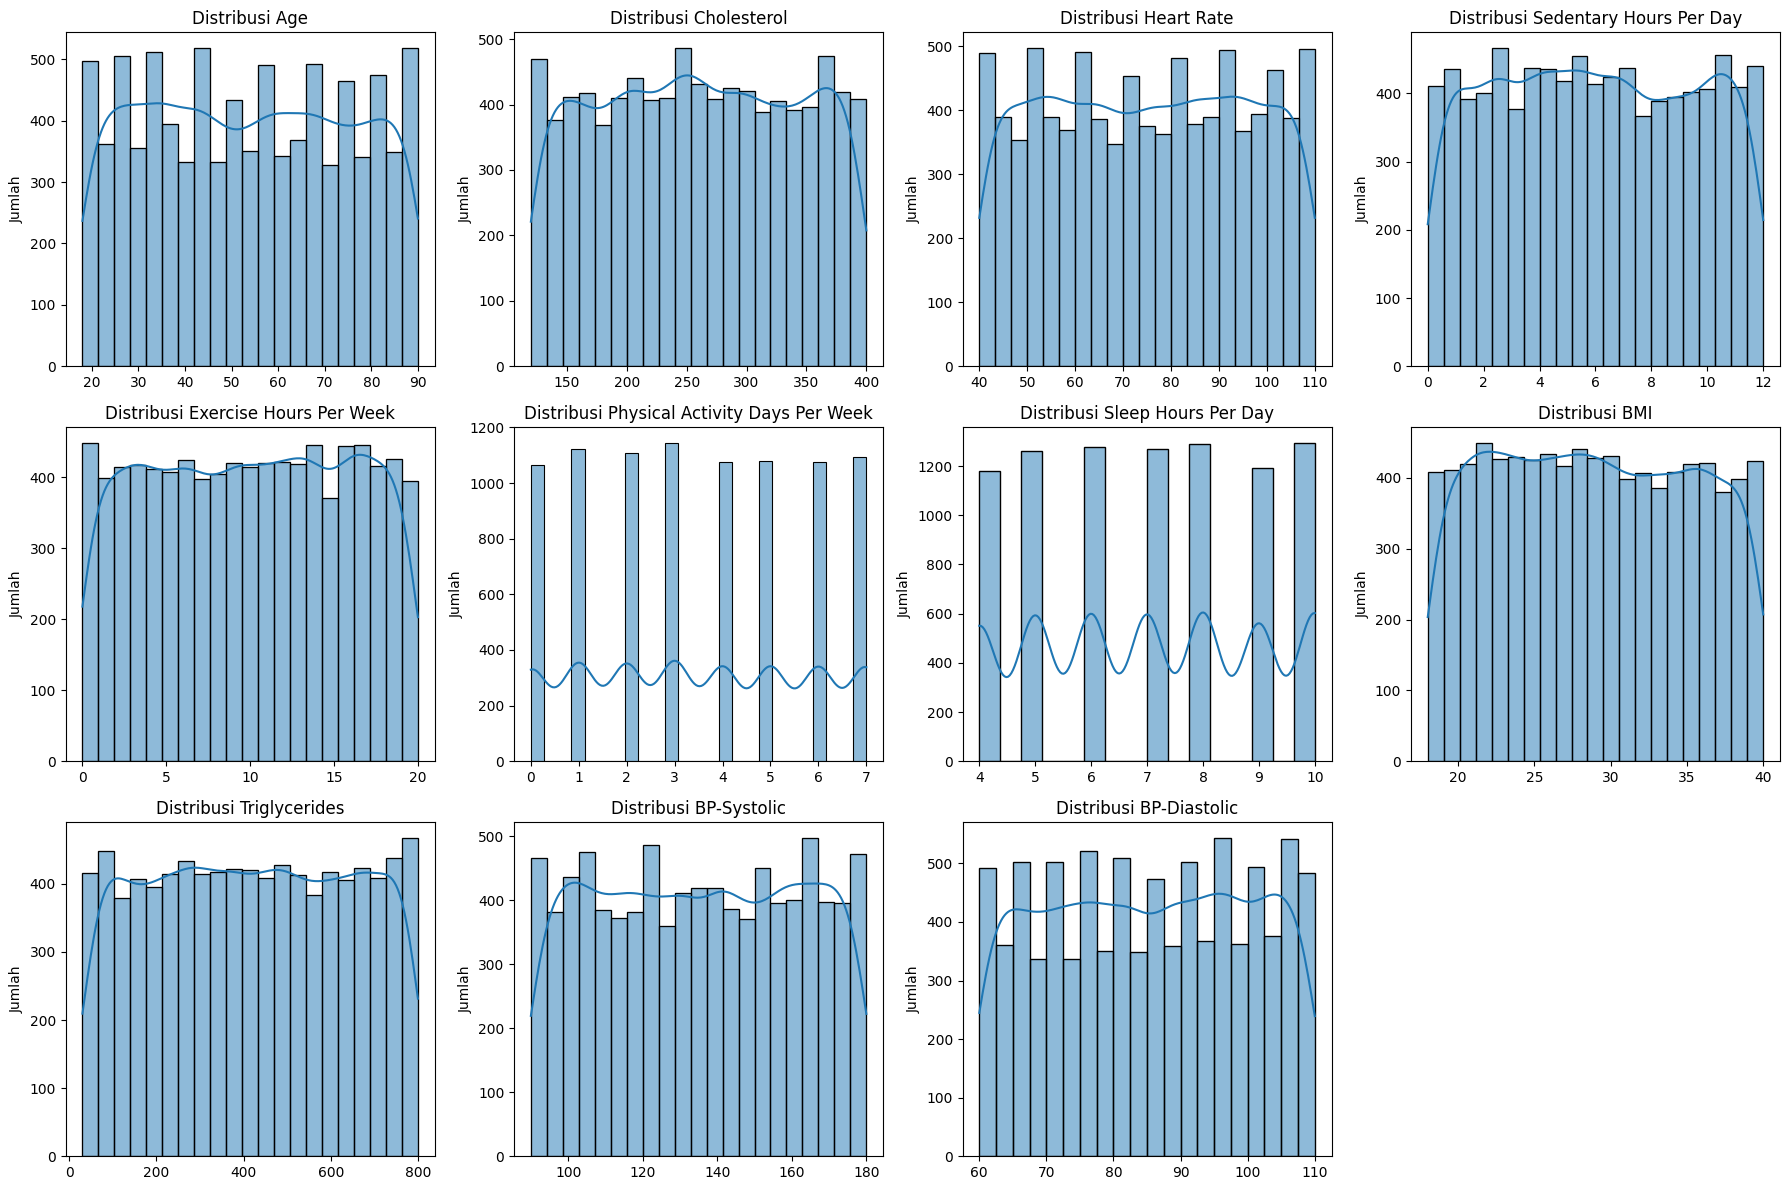

In [ ]:
num_feature = ['Age','Cholesterol', 'Heart Rate', 'Sedentary Hours Per Day',
                  'Exercise Hours Per Week', 'Physical Activity Days Per Week',
                  'Sleep Hours Per Day', 'BMI', 'Triglycerides', 'BP-Systolic', 'BP-Diastolic']

cols = 4
rows = math.ceil(len(num_feature) / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(18, rows*4))

axes = axes.flatten()

for i, col in enumerate(num_feature):
   sns.histplot(x=col, data=df_copy, ax = axes[i], kde=True)
   axes[i].set_title(f'Distribusi {col}', fontsize=12)
   axes[i].set_xlabel('')
   axes[i].set_ylabel('Jumlah')
# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

1. **Distribusi Data yang Merata**

Sebagian besar variabel numerik dalam dataset ini menunjukkan pola distribusi yang cukup merata (uniform). Artinya, nilai data tersebar relatif seimbang di seluruh rentang yang tersedia dan tidak terlalu menumpuk pada nilai tertentu.

- Usia (Age)

Rentang usia dalam dataset berkisar dari sekitar 20 hingga 90 tahun, dengan jumlah sampel yang relatif merata di setiap kelompok umur. Hal ini menunjukkan bahwa dataset mencakup populasi dari berbagai tahap usia secara cukup seimbang.

- Faktor Fisik

Variabel seperti BMI (18–40), Cholesterol (120–400), Heart Rate (40–110), dan Triglycerides juga menunjukkan pola yang cukup merata. Nilai-nilai tersebut tersebar di seluruh rentangnya tanpa membentuk pola kurva normal yang biasanya muncul pada data observasi nyata.

- Insight:

Pola distribusi sangat merata, ini mengindikasikan bahwa dataset kemungkinan dirancang atau disimulasikan untuk mencakup seluruh rentang nilai secara seimbang. Hal ini berbeda dengan data alami yang biasanya cenderung berkumpul di sekitar nilai rata-rata.

2. **Pola Gaya Hidup dan Kebiasaan**

Beberapa variabel yang menggambarkan gaya hidup juga menunjukkan distribusi yang cukup seimbang.

- Physical Activity Days per Week

Jumlah hari aktivitas fisik dalam seminggu tersebar dari 0 hingga 7 hari, dengan distribusi yang relatif merata.

- Sleep Hours per Day

Durasi tidur berkisar antara 4 hingga 10 jam per hari. Menariknya, jumlah individu yang tidur lebih sedikit (misalnya 4 jam) terlihat tidak jauh berbeda dengan mereka yang tidur lebih lama seperti 8 atau 10 jam.

- Sedentary Hours

Waktu tidak aktif per hari tersebar antara 0 hingga 12 jam, menunjukkan variasi tingkat aktivitas harian yang cukup luas.

- Exercise Hours per Week

Durasi olahraga mingguan berkisar antara 0 hingga 20 jam, dengan distribusi yang cukup stabil di berbagai rentang waktu.

3. **Profil Tekanan Darah**

Variabel tekanan darah dalam dataset mencakup rentang nilai yang cukup luas.

- BP Systolic memiliki nilai sekitar 90 hingga 180 mmHg.

- BP Diastolic berkisar antara 60 hingga 110 mmHg.

## Bivariate Analysis & Outlier Check

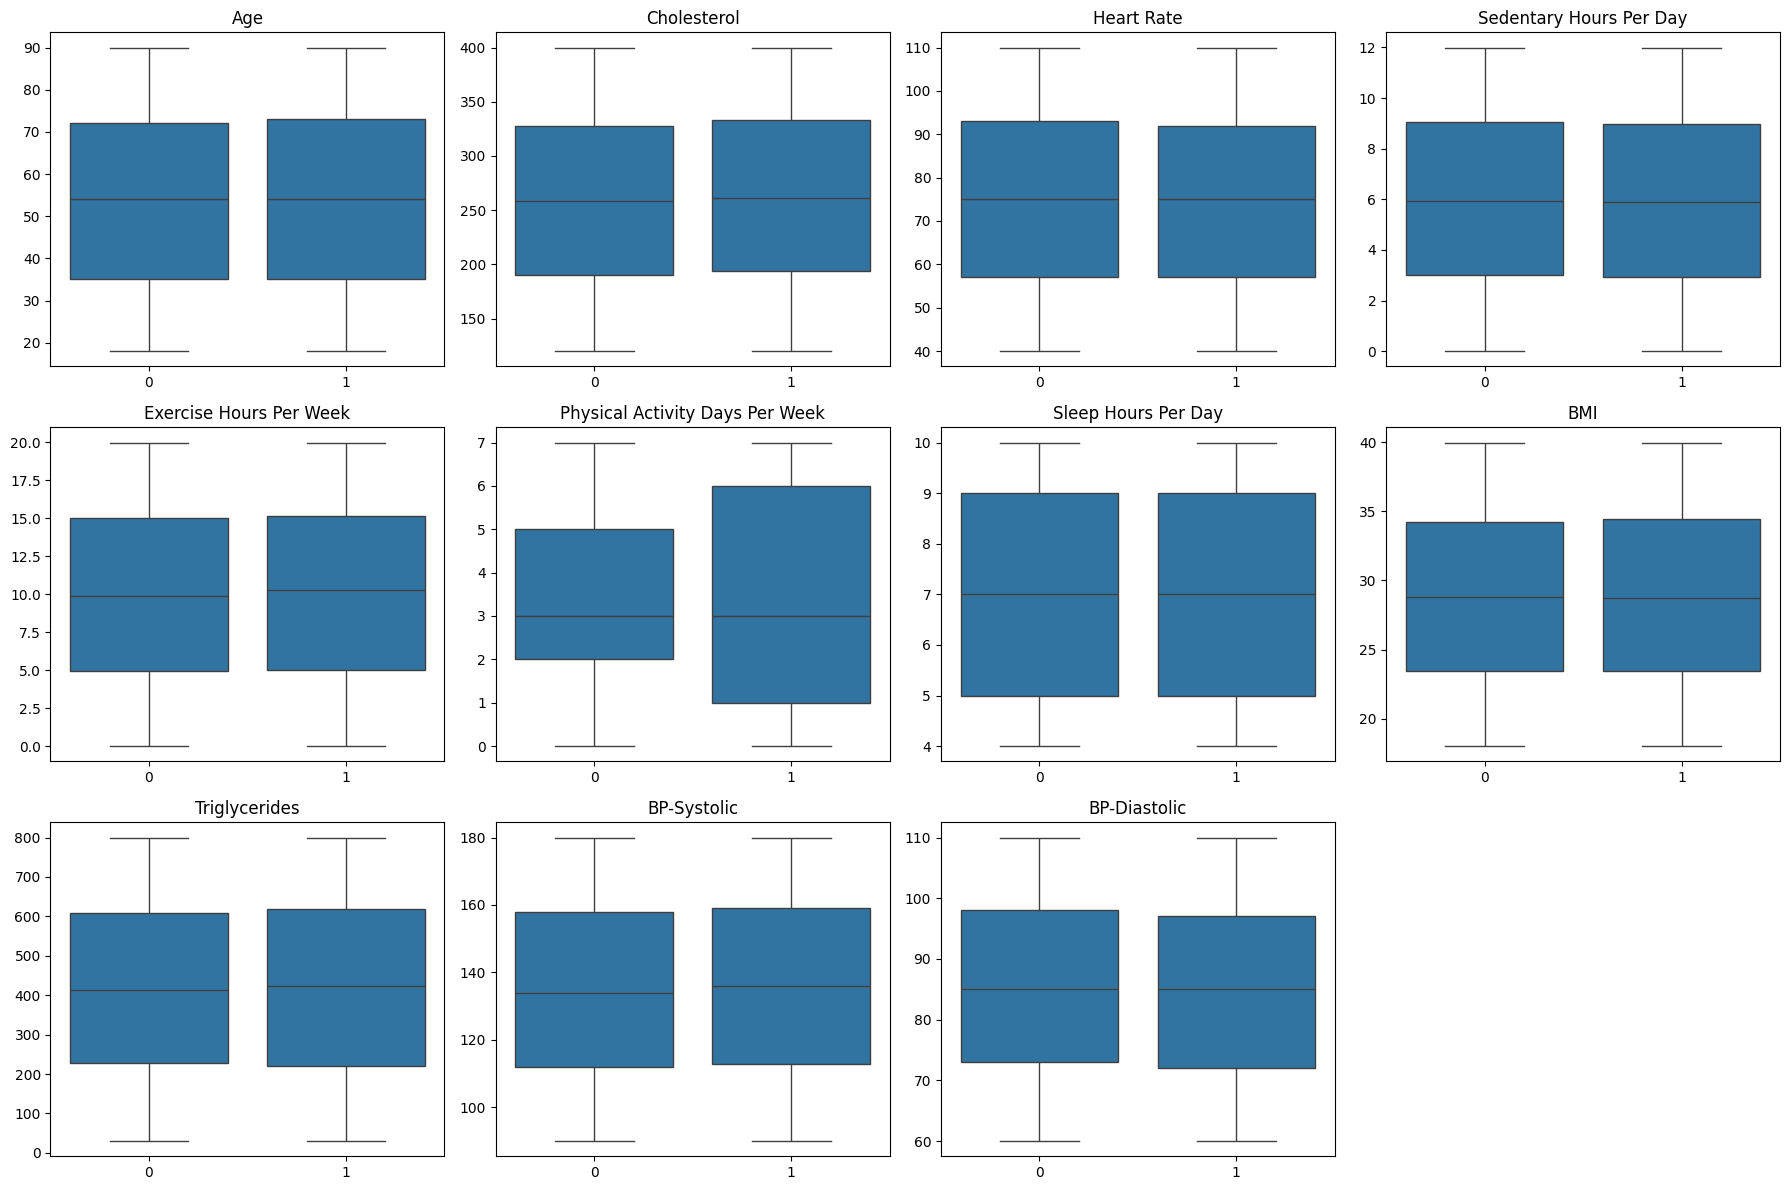

In [ ]:
cols = 4
rows = math.ceil(len(num_feature) / cols)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(18, rows*4))
axes = axes.flatten()

for i, col in enumerate(num_feature):
    sns.boxplot(x='Heart Attack Risk', y=col, data=df_copy, ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. **Korelasi Linier yang Lemah**

Secara visual, median (garis tengah di dalam kotak) dan rentang antarkuartil (kotak biru) untuk hampir semua variabel terlihat hampir identik antara kelompok 0 dan 1.

Age, Cholesterol, BMI, dan Blood Pressure: Tidak ada perbedaan signifikan secara visual pada nilai tengahnya. Artinya, dalam dataset ini, seseorang dengan kolesterol tinggi atau usia tua tidak secara otomatis langsung dikategorikan berisiko tinggi jika hanya dilihat dari satu variabel ini saja secara terpisah.

2. **Perbedaan Tipis pada Variabel Tertentu**

Jika diperhatikan dengan sangat teliti, ada sedikit pergeseran pada beberapa variabel:

- Physical Activity Days Per Week

Pada kelompok risiko 1, sebaran datanya tampak sedikit lebih luas ke atas pada kuartil atasnya, namun secara keseluruhan mediannya tetap serupa.

- Exercise Hours Per Week

Kelompok risiko 1 menunjukkan median yang sedikit lebih tinggi dibandingkan kelompok 0. Ini mungkin terlihat kontra-intuitif (lebih banyak olahraga tapi risiko lebih tinggi), yang menguatkan indikasi bahwa data ini kemungkinan besar bersifat sintetis atau memiliki interaksi fitur yang kompleks (bukan hubungan sebab-akibat sederhana).

- Triglycerides & BP-Systolic

Ada pergeseran median yang sangat tipis ke arah nilai yang lebih tinggi pada kelompok risiko 1.

3. **Tidak Ada Outliers yang Terdeteksi**

Dalam boxplot ini, tidak terlihat adanya titik-titik di luar "kumis" (whiskers). Ini mengonfirmasi insight dari histogram sebelumnya bahwa data ini tersebar merata dalam rentang yang sudah ditentukan tanpa ada nilai yang sangat ekstrem atau anomali.

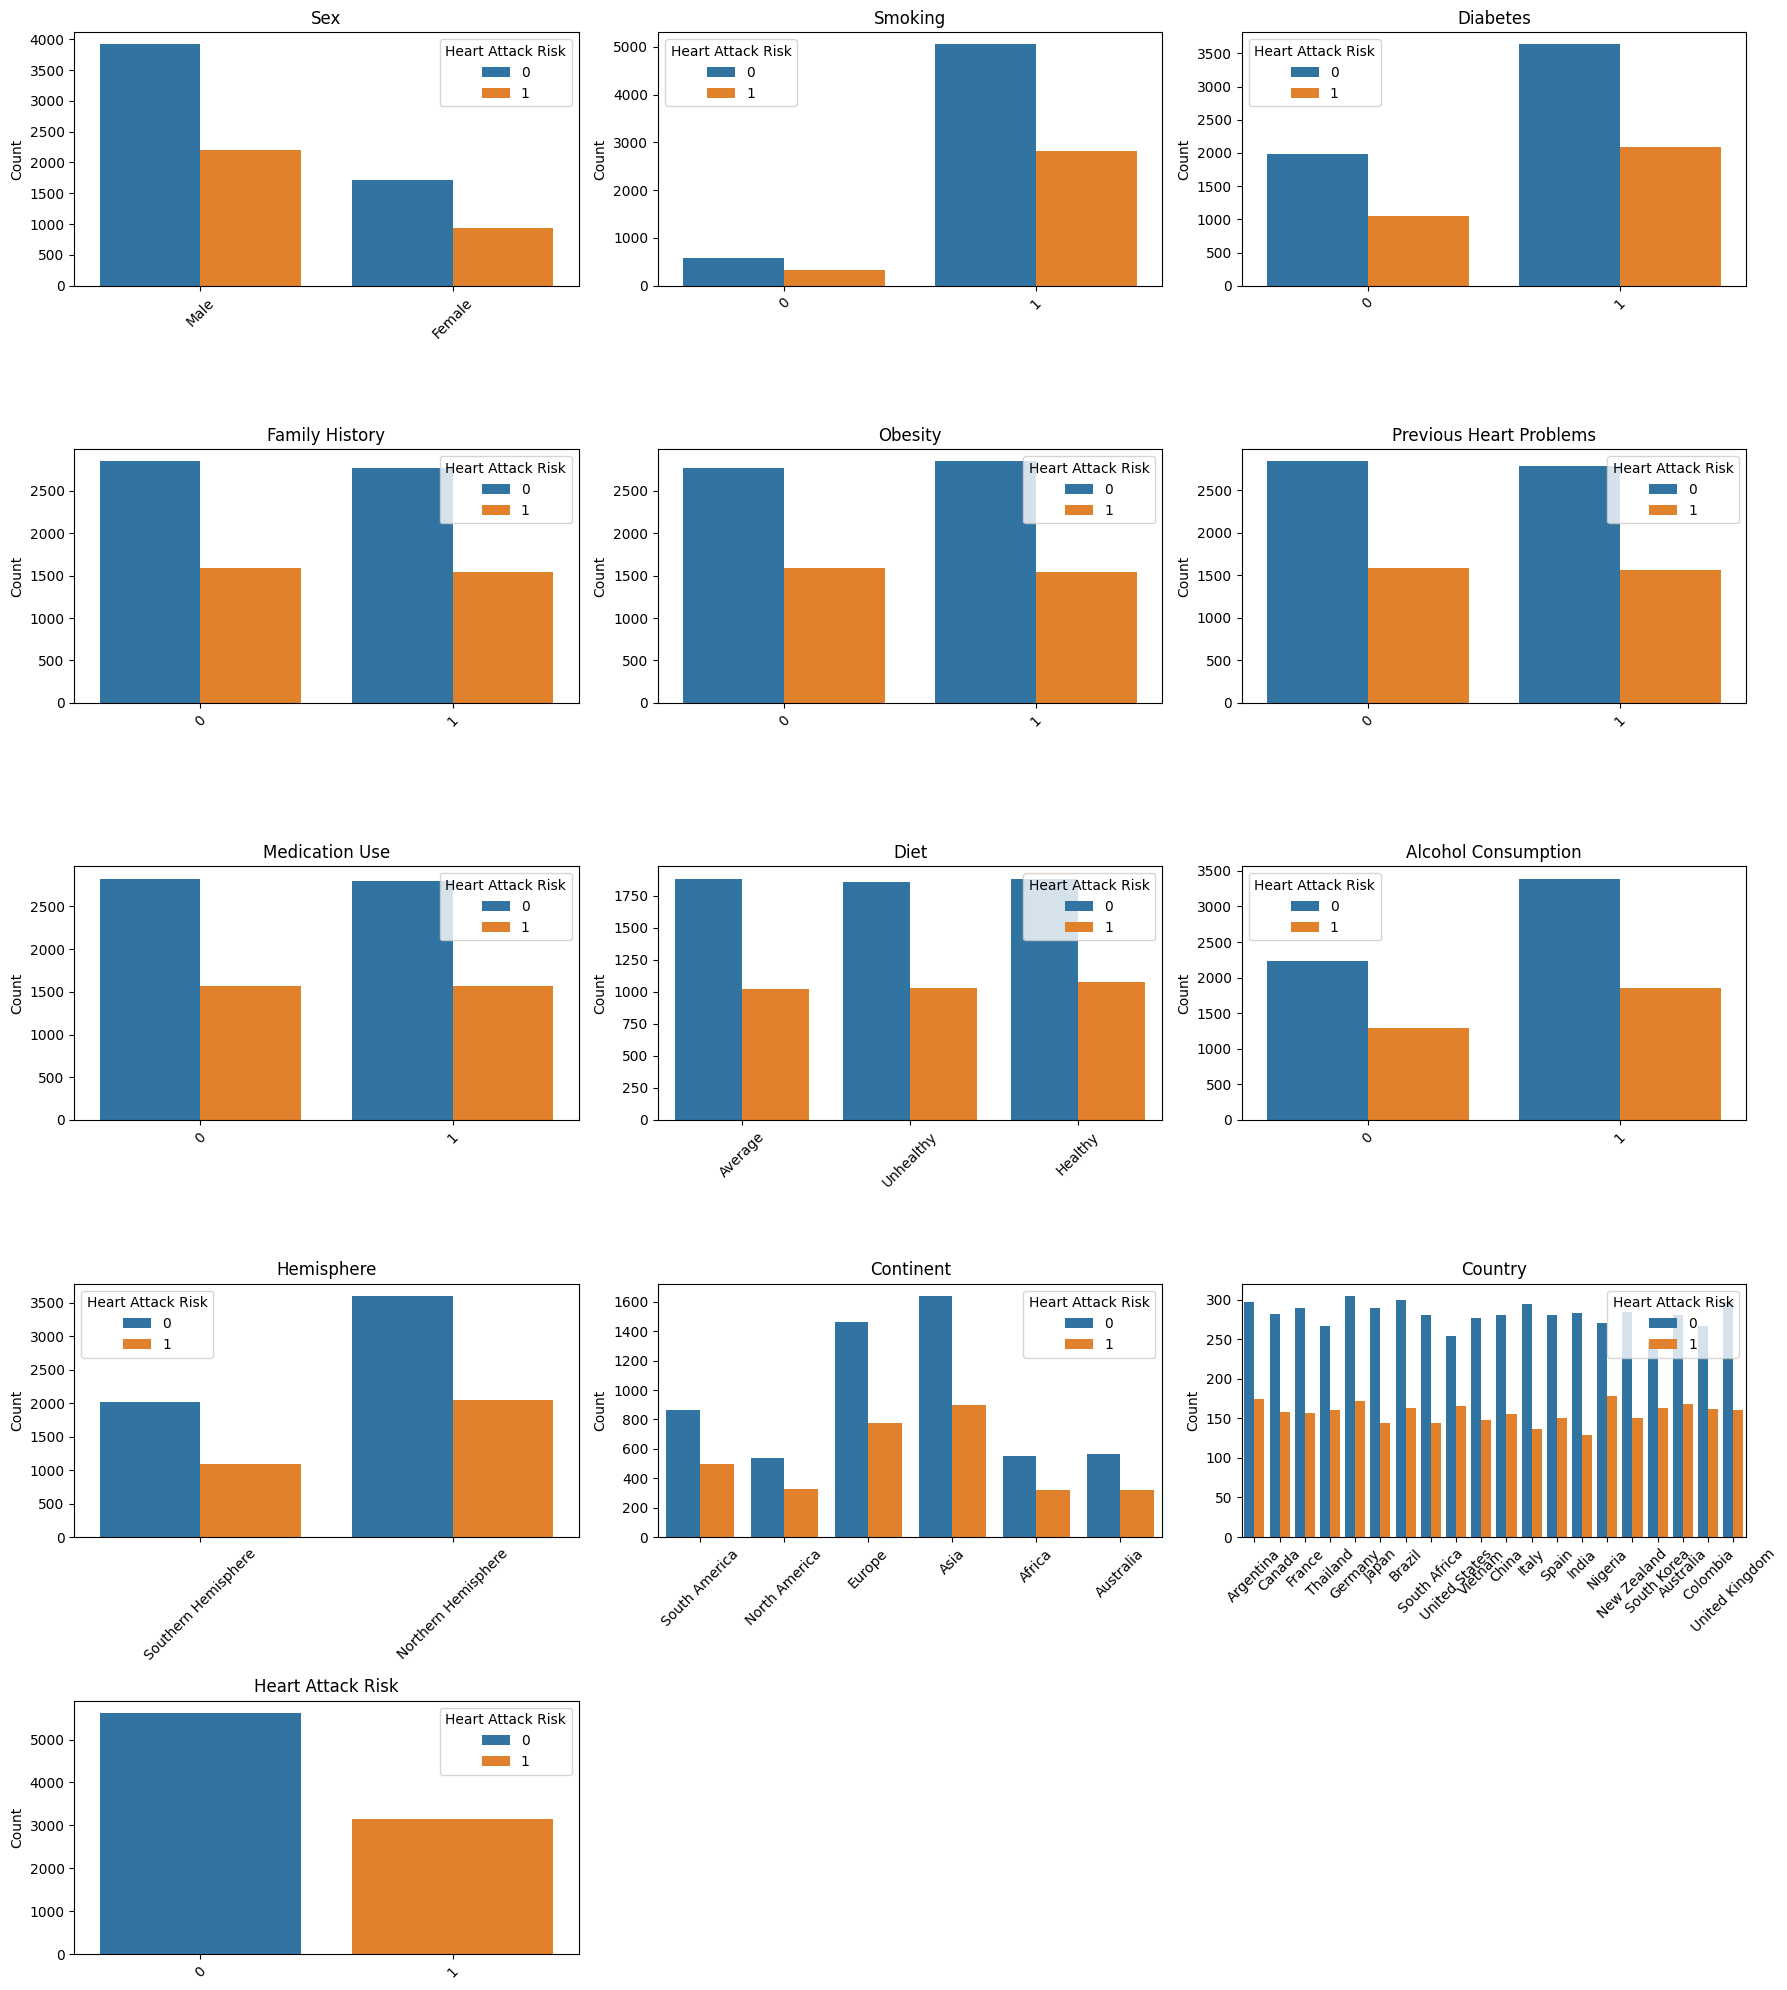

In [ ]:
cols = 3
rows = math.ceil(len(cat) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows*4))
axes = axes.flatten()

for i, col in enumerate(cat):
    sns.countplot(x=col, hue='Heart Attack Risk', data=df_copy, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. **Konsistensi Rasio Risiko**

Salah satu pola yang paling terlihat dari grafik adalah konsistensi proporsi risiko serangan jantung pada berbagai kategori variabel. Pada hampir semua variabel seperti jenis kelamin, riwayat keluarga, obesitas, penggunaan obat, hingga jenis diet, perbandingan antara kelompok tanpa risiko (0) dan berisiko (1) terlihat relatif serupa.

Hal ini menunjukkan bahwa tidak ada satu variabel kategorikal yang secara langsung menjadi penentu utama risiko serangan jantung jika dilihat secara terpisah. Sebagai contoh, proporsi risiko pada individu dengan diet sehat tidak menunjukkan perbedaan yang terlalu jauh dibandingkan dengan mereka yang memiliki diet tidak sehat.

- Insight:

Risiko serangan jantung dalam dataset ini kemungkinan tidak dipengaruhi oleh satu faktor saja, melainkan oleh kombinasi beberapa faktor yang saling berinteraksi.

2. **Insight pada Beberapa Variabel**

Meskipun proporsi risiko terlihat konsisten, beberapa variabel tetap memberikan informasi menarik.

- Smoking

Jumlah individu yang merokok terlihat jauh lebih besar dibandingkan yang tidak merokok. Namun, jika dilihat dari proporsi risiko di dalam masing-masing kelompok, distribusinya masih mengikuti pola umum dataset. Artinya, meskipun merokok merupakan faktor risiko, dalam dataset ini pengaruhnya tidak terlihat dominan jika dilihat secara tunggal.

- Diabetes

Hal yang sama juga terlihat pada variabel diabetes. Kelompok individu dengan diabetes memang memiliki jumlah yang lebih besar, namun distribusi risiko serangan jantung di dalamnya tetap mengikuti pola distribusi keseluruhan dataset.

- Geografi (Continent dan Country)

Distribusi risiko serangan jantung juga terlihat relatif merata di berbagai wilayah dunia. Tidak ada benua atau negara tertentu yang menunjukkan peningkatan risiko yang sangat signifikan dibandingkan wilayah lainnya.

- Insight:

Hal ini menunjukkan bahwa risiko serangan jantung dalam dataset tidak terpusat pada kelompok geografis tertentu, sehingga analisis dapat dilakukan secara lebih umum tanpa dominasi wilayah tertentu.

3. **Ketidakseimbangan Data (Class Imbalance)**

Grafik Heart Attack Risk menunjukkan bahwa jumlah individu yang tidak berisiko (label 0) jauh lebih besar dibandingkan individu yang berisiko (label 1). Ketidakseimbangan ini juga terlihat pada berbagai grafik kategori lainnya.

- Insight:

Kondisi ini menunjukkan adanya class imbalance dalam dataset. Jika digunakan untuk membangun model machine learning, model berpotensi lebih sering memprediksi kelas mayoritas (0) untuk mencapai akurasi tinggi. Oleh karena itu, perlu dipertimbangkan teknik penanganan imbalance seperti resampling atau penyesuaian parameter model agar prediksi terhadap kelas minoritas tetap akurat.

## Encoding

drop feature tidak penting dulu

In [ ]:
df_processed = df_copy.drop(columns=['Patient ID', 'Income', 'Hemisphere', 'Continent', 'Country' ])
df_processed

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,BP-Systolic,BP-Diastolic
0,67,Male,208,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,31.251233,286,0,6,0,158,88
1,21,Male,389,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,27.194973,235,1,7,0,165,93
2,21,Female,324,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,28.176571,587,4,4,0,174,99
3,84,Male,383,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,36.464704,378,3,4,0,163,100
4,66,Male,318,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,21.809144,231,1,5,0,91,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,Male,121,61,1,1,1,0,1,7.917342,Healthy,1,1,8,10.806373,19.655895,67,7,7,0,94,76
8759,28,Female,120,73,1,0,0,1,0,16.558426,Healthy,0,0,8,3.833038,23.993866,617,4,9,0,157,102
8760,47,Male,250,105,0,1,1,1,1,3.148438,Average,1,0,5,2.375214,35.406146,527,4,4,1,161,75
8761,36,Male,178,60,1,0,1,0,0,3.789950,Unhealthy,1,1,5,0.029104,27.294020,114,2,8,0,119,67


### Label

In [ ]:
# Label Encode Binary data
leEncoders = {}
le = LabelEncoder()

binary_cols = [col for col in df_processed.columns[1:] if df_processed[col].dtype == 'object' and len(df_processed[col].unique()) <= 2]

for col in binary_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    leEncoders[col] = le  # save the encoder for this column
    print(f"{col} column was label encoded.")

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(leEncoders, f)

print(f"{len(binary_cols)} columns were label encoded.")
df_processed

Sex column was label encoded.
1 columns were label encoded.


,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,BP-Systolic,BP-Diastolic
0,67,1,208,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,31.251233,286,0,6,0,158,88
1,21,1,389,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,27.194973,235,1,7,0,165,93
2,21,0,324,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,28.176571,587,4,4,0,174,99
3,84,1,383,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,36.464704,378,3,4,0,163,100
4,66,1,318,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,21.809144,231,1,5,0,91,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,1,121,61,1,1,1,0,1,7.917342,Healthy,1,1,8,10.806373,19.655895,67,7,7,0,94,76
8759,28,0,120,73,1,0,0,1,0,16.558426,Healthy,0,0,8,3.833038,23.993866,617,4,9,0,157,102
8760,47,1,250,105,0,1,1,1,1,3.148438,Average,1,0,5,2.375214,35.406146,527,4,4,1,161,75
8761,36,1,178,60,1,0,1,0,0,3.789950,Unhealthy,1,1,5,0.029104,27.294020,114,2,8,0,119,67


### One hot

In [ ]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int, drop='first')

# Encode feature dengan jumlah unique value 3-10
multiple_cols = [
    col for col in df_processed.columns[1:]
    if df_processed[col].dtype == 'object' and 3 <= len(df_processed[col].unique()) <= 10
]

ohe.fit(df_processed[multiple_cols])
encoded_array = ohe.transform(df_processed[multiple_cols])
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(multiple_cols),
    index=df_processed.index
)

# Drop ori feature
df_processed = df_processed.drop(columns=multiple_cols).join(encoded_df)

with open('onehot_encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)

print(f"{len(multiple_cols)} columns were one hot encoded with drop first.")
df_processed

1 columns were one hot encoded with drop first.


,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,31.251233,286,0,6,0,158,88,0,0
1,21,1,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,27.194973,235,1,7,0,165,93,0,1
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,28.176571,587,4,4,0,174,99,1,0
3,84,1,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,36.464704,378,3,4,0,163,100,0,0
4,66,1,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,21.809144,231,1,5,0,91,88,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,1,121,61,1,1,1,0,1,7.917342,1,1,8,10.806373,19.655895,67,7,7,0,94,76,1,0
8759,28,0,120,73,1,0,0,1,0,16.558426,0,0,8,3.833038,23.993866,617,4,9,0,157,102,1,0
8760,47,1,250,105,0,1,1,1,1,3.148438,1,0,5,2.375214,35.406146,527,4,4,1,161,75,0,0
8761,36,1,178,60,1,0,1,0,0,3.789950,1,1,5,0.029104,27.294020,114,2,8,0,119,67,0,1


### Mean Based Encode

In [ ]:
if 'Country' in df_processed.columns:
    # Mean risk/country
    country_risk_map = df_processed.groupby('Country')['Heart Attack Risk'].mean().to_dict()

    # Hitung global mean
    global_mean_risk = df_processed['Heart Attack Risk'].mean()

    # Mapping dengan default
    df_processed['Country_risk_encoded'] = df_processed['Country'].map(lambda x: country_risk_map.get(x, global_mean_risk))
    # Drop column
    df_processed.drop(columns = ['Country'], inplace = True)
    # Save mapping & global mean
    risk_encoder = {
        'mapping': country_risk_map,
        'global_mean': global_mean_risk
    }

    with open('risk_encoder.pkl', 'wb') as f:
        pickle.dump(risk_encoder, f)
df_processed

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,31.251233,286,0,6,0,158,88,0,0
1,21,1,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,27.194973,235,1,7,0,165,93,0,1
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,28.176571,587,4,4,0,174,99,1,0
3,84,1,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,36.464704,378,3,4,0,163,100,0,0
4,66,1,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,21.809144,231,1,5,0,91,88,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,1,121,61,1,1,1,0,1,7.917342,1,1,8,10.806373,19.655895,67,7,7,0,94,76,1,0
8759,28,0,120,73,1,0,0,1,0,16.558426,0,0,8,3.833038,23.993866,617,4,9,0,157,102,1,0
8760,47,1,250,105,0,1,1,1,1,3.148438,1,0,5,2.375214,35.406146,527,4,4,1,161,75,0,0
8761,36,1,178,60,1,0,1,0,0,3.789950,1,1,5,0.029104,27.294020,114,2,8,0,119,67,0,1


In [ ]:
df_processed['Heart Attack Risk'] = df_processed.pop('Heart Attack Risk')
df_processed.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy,Heart Attack Risk
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,31.251233,286,0,6,158,88,0,0,0
1,21,1,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,27.194973,235,1,7,165,93,0,1,0
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,28.176571,587,4,4,174,99,1,0,0
3,84,1,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,36.464704,378,3,4,163,100,0,0,0
4,66,1,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,21.809144,231,1,5,91,88,0,1,0


## **Multivariate Analysis**

### Membuat Heatmap Korelasi

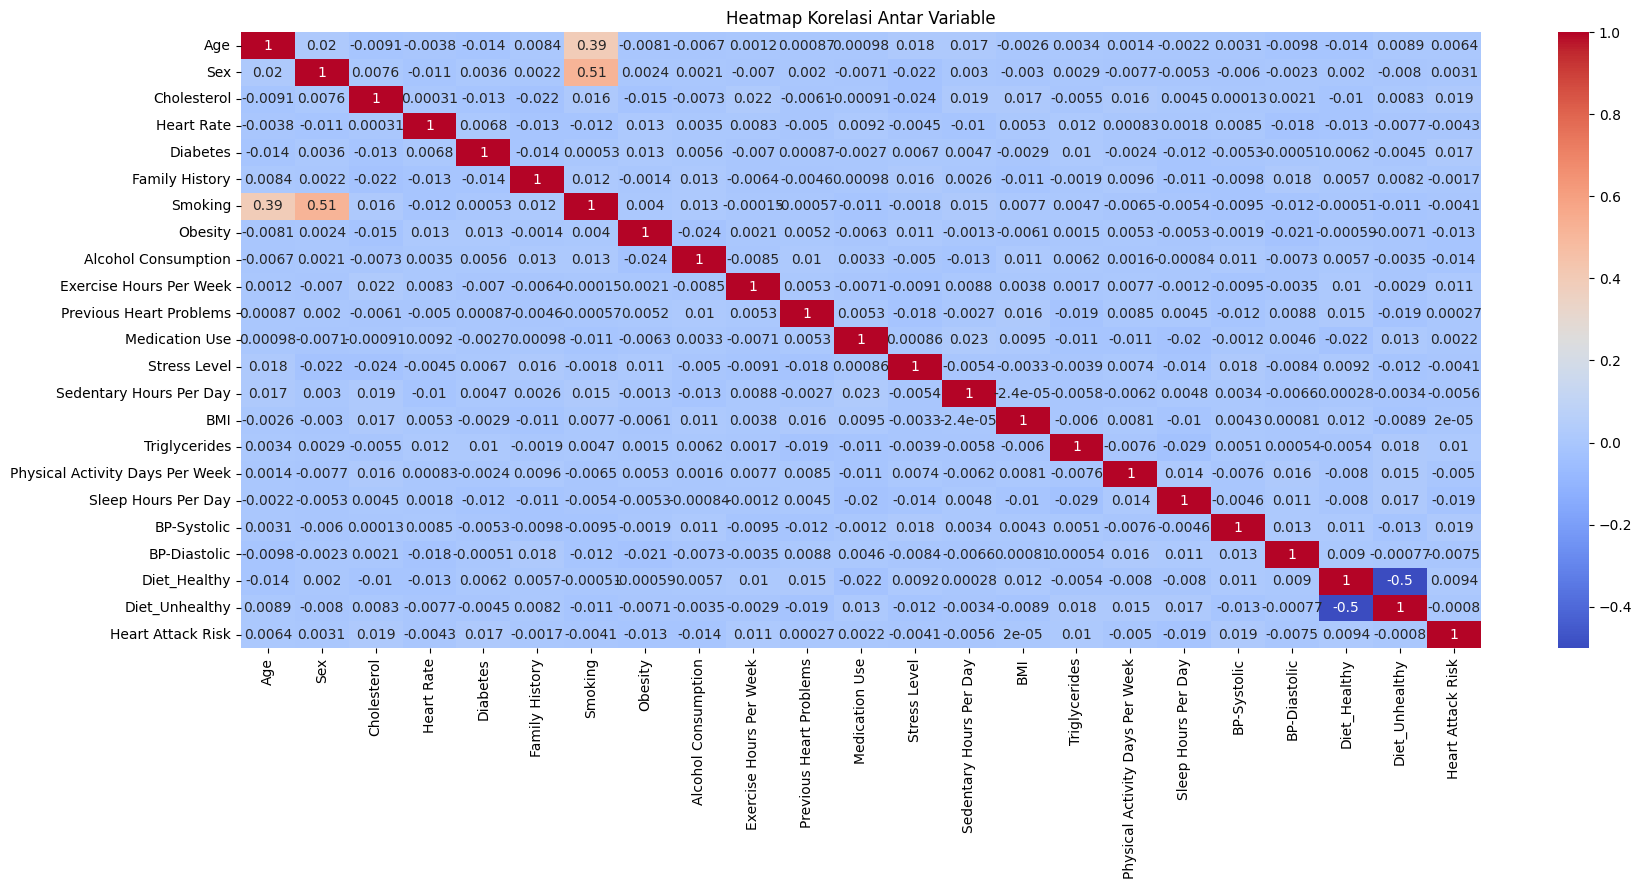

In [ ]:
corr = df_processed.corr()

plt.figure(figsize = (20, 8))
sns.heatmap(corr, annot = True, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Variable')
plt.show()

- Korelasi Lemah terhadap Target: Baris paling bawah (Heart Attack Risk) menunjukkan nilai mendekati 0 untuk hampir semua fitur. Artinya, tidak ada fitur tunggal yang secara kuat memprediksi risiko serangan jantung secara linier.

- Hubungan Tertinggi: Korelasi yang paling terlihat hanya ada pada variabel demografi/kebiasaan dasar, yaitu antara Smoking dengan Age (0.39) dan Sex (0.51). Selebihnya hampir tidak ada hubungan yang signifikan (area biru dominan).

- Multikolinieritas Rendah: Tidak ada dua fitur independen yang saling berhubungan sangat kuat (kecuali Diet_Healthy dan Diet_Unhealthy karena memang berlawanan). Ini bagus untuk model karena setiap fitur membawa informasi yang unik.

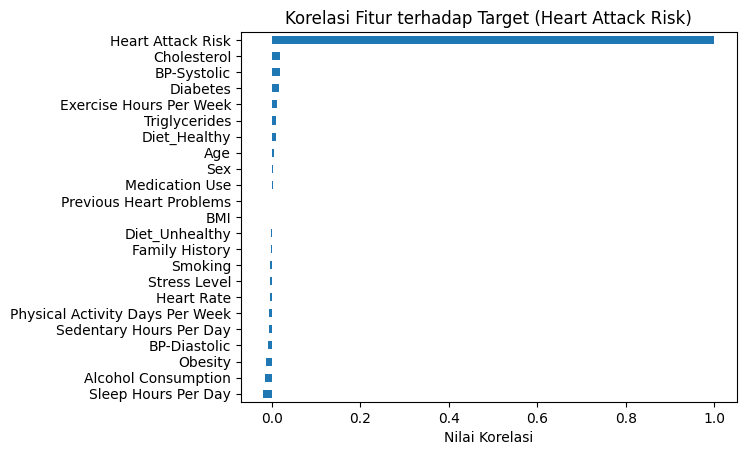

In [ ]:
corr_target = corr['Heart Attack Risk'].sort_values(ascending=True)
corr_target.plot(kind='barh')
plt.title("Korelasi Fitur terhadap Target (Heart Attack Risk)")
plt.xlabel("Nilai Korelasi")
plt.show()



> **Korelasi masing-masing fitur terhadap target (Heart Attack Risk) menunjukkan bahwa tidak ada fitur dengan hubungan linear yang kuat terhadap target.**



## Unsupervised (Clustering)

In [ ]:
df_clustering = df_processed.drop(columns=['Heart Attack Risk'])

In [ ]:
df_clustering

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,31.251233,286,0,6,158,88,0,0
1,21,1,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,27.194973,235,1,7,165,93,0,1
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,28.176571,587,4,4,174,99,1,0
3,84,1,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,36.464704,378,3,4,163,100,0,0
4,66,1,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,21.809144,231,1,5,91,88,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,1,121,61,1,1,1,0,1,7.917342,1,1,8,10.806373,19.655895,67,7,7,94,76,1,0
8759,28,0,120,73,1,0,0,1,0,16.558426,0,0,8,3.833038,23.993866,617,4,9,157,102,1,0
8760,47,1,250,105,0,1,1,1,1,3.148438,1,0,5,2.375214,35.406146,527,4,4,161,75,0,0
8761,36,1,178,60,1,0,1,0,0,3.789950,1,1,5,0.029104,27.294020,114,2,8,119,67,0,1


In [ ]:
scaler_cluster = StandardScaler()
X_clustering = scaler_cluster.fit_transform(df_clustering)
X_clustering

array([[ 0.62555713,  0.65876515, -0.64157889, ...,  0.19378181,
        -0.71419955, -0.70166695],
       [-1.53932232,  0.65876515,  1.59689495, ...,  0.53448043,
        -0.71419955,  1.42517757],
       [-1.53932232, -1.51799165,  0.79302313, ...,  0.94331876,
         1.40016891, -0.70166695],
       ...,
       [-0.3156948 ,  0.65876515, -0.12215402, ..., -0.69203458,
        -0.71419955, -0.70166695],
       [-0.83338337,  0.65876515, -1.01259666, ..., -1.23715237,
        -0.71419955,  1.42517757],
       [-1.35107193, -1.51799165,  1.18877541, ..., -1.23715237,
         1.40016891, -0.70166695]], shape=(8763, 22))

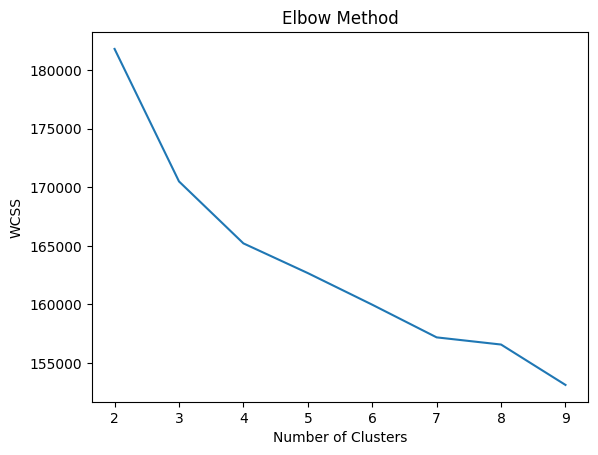

In [ ]:
wcss = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=random_state_value)
    kmeans.fit(X_clustering)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

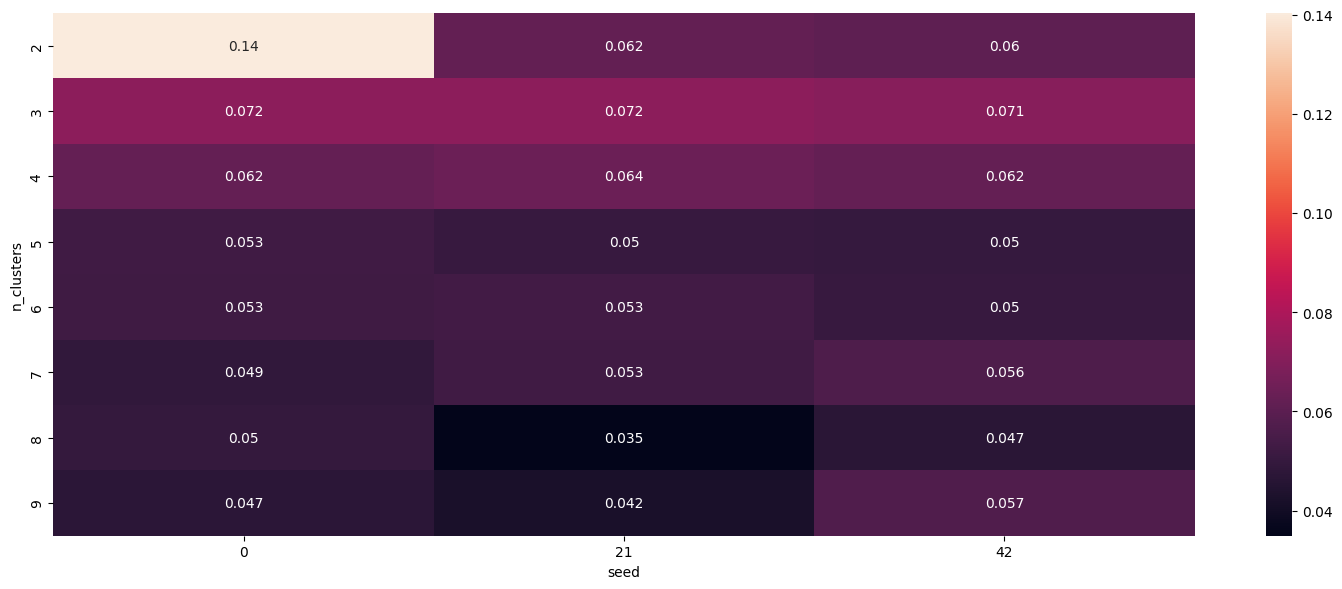

In [ ]:
random_range = [0, int(random_state_value/2), random_state_value]
results = []

for c in range(2,10):
    for r in random_range:
        clusterer = KMeans(n_clusters= c, random_state=r, init="k-means++")
        cluster_labels = clusterer.fit_predict(X_clustering)
        silhoutte_avg = silhouette_score(X_clustering, cluster_labels, random_state=r)
        results.append([c,r,silhoutte_avg])
results = pd.DataFrame(results, columns=("n_clusters","seed","silhouette_score"))

#Pivot
pivot = pd.pivot_table(results, index="n_clusters", columns="seed", values="silhouette_score")

#Heatmap
plt.figure(figsize=(15,6))
sns.heatmap(pivot, annot=True)
plt.tight_layout()

### Hasil Cluster
Cluster paling bagus **2**

In [ ]:
n_clusters = 2
pd.DataFrame(X_clustering, columns=df_clustering.columns)

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy
0,0.625557,0.658765,-0.641579,-0.147042,-1.369651,-0.986061,0.339157,-1.002857,-1.219867,-1.010838,-0.991704,-0.996696,1.234604,0.179251,0.373454,-0.588539,-1.528843,-0.514750,0.870044,0.193782,-0.714200,-0.701667
1,-1.539322,0.658765,1.596895,1.118179,0.730113,1.014136,0.339157,0.997151,0.819762,-1.418027,1.008365,-0.996696,-1.563129,-0.297225,-0.268479,-0.816487,-1.090738,-0.011823,1.135714,0.534480,-0.714200,1.425178
2,-1.539322,-1.517992,0.793023,-0.147042,0.730113,-0.986061,-2.948488,-1.002857,-1.219867,-1.372188,1.008365,1.003315,1.234604,1.001031,-0.113134,0.756800,0.223577,-1.520604,1.477290,0.943319,1.400169,-0.701667
3,1.425621,0.658765,1.522691,-0.098380,0.730113,1.014136,0.339157,-1.002857,0.819762,-0.032188,1.008365,-0.996696,1.234604,0.477557,1.198524,-0.177339,-0.214528,-1.520604,1.059809,1.011458,-0.714200,-0.701667
4,0.578495,0.658765,0.718820,0.874867,0.730113,1.014136,0.339157,0.997151,-1.219867,-0.727941,1.008365,-0.996696,0.185454,-1.292170,-1.120826,-0.834365,-1.090738,-1.017677,-1.672797,0.193782,-0.714200,1.425178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,0.296119,0.658765,-1.717530,-0.682328,0.730113,1.014136,0.339157,-1.002857,0.819762,-0.362578,1.008365,1.003315,0.884887,1.388476,-1.461594,-1.567374,1.537893,-0.011823,-1.558939,-0.623895,1.400169,-0.701667
8759,-1.209884,-1.517992,-1.729898,-0.098380,0.730113,-0.986061,-2.948488,0.997151,-1.219867,1.131536,-0.991704,-0.996696,0.884887,-0.623356,-0.775078,0.890887,0.223577,0.994032,0.832092,1.147738,1.400169,-0.701667
8760,-0.315695,0.658765,-0.122154,1.458815,-1.369651,1.014136,0.339157,0.997151,0.819762,-1.187161,1.008365,-0.996696,-0.164263,-1.043943,1.030999,0.488626,0.223577,-1.520604,0.983903,-0.692035,-0.714200,-0.701667
8761,-0.833383,0.658765,-1.012597,-0.730990,0.730113,-0.986061,0.339157,-1.002857,-1.219867,-1.076238,1.008365,1.003315,-0.164263,-1.720804,-0.252804,-1.357305,-0.652633,0.491104,-0.610117,-1.237152,-0.714200,1.425178


### PCA Visualization

In [ ]:
#PCA (Pengurangan Dimensi dataset dari 7 kolom menjadi 3 kolom)
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=random_state_value)
X_pca = pca.fit_transform(X_clustering)
X_pca_df = pd.DataFrame(data=X_pca, columns=['X1','X2','X3'])
X_pca_df

,X1,X2,X3
0,0.876269,-0.084141,-0.929666
1,-0.058261,1.347431,0.683787
2,-3.596964,-1.595792,-0.485793
3,1.301226,-0.188318,0.036282
4,0.840412,1.450552,-0.714434
...,...,...,...
8758,0.780754,-1.455817,-0.366188
8759,-3.554671,-1.569142,-1.283909
8760,0.493092,-0.142632,-0.965691
8761,0.145046,1.467507,0.013768


In [ ]:
# Jalankan algoritma Clustering (KMeans) terhadap data yang sudah di PCA
# Kita memilih menggunakan 2 cluster
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state_value, init="k-means++").fit(X_pca)
labels = kmeans.labels_
X_pca_df['Labels'] = labels
X_pca_df

,X1,X2,X3,Labels
0,0.876269,-0.084141,-0.929666,1
1,-0.058261,1.347431,0.683787,1
2,-3.596964,-1.595792,-0.485793,0
3,1.301226,-0.188318,0.036282,1
4,0.840412,1.450552,-0.714434,1
...,...,...,...,...
8758,0.780754,-1.455817,-0.366188,0
8759,-3.554671,-1.569142,-1.283909,0
8760,0.493092,-0.142632,-0.965691,1
8761,0.145046,1.467507,0.013768,1


In [ ]:
#Jumlah value per label
X_pca_df['Labels'].value_counts()

Labels
1    5474
0    3289
Name: count, dtype: int64

In [ ]:
import plotly.express as px

fig = px.scatter_3d(X_pca_df, x='X1', y='X2', z='X3', color=X_pca_df['Labels'])
fig.show()

In [ ]:
df_cluster_result = df_processed.copy()
df_cluster_result['Cluster'] = kmeans.labels_
df_cluster_result

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy,Heart Attack Risk,Cluster
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,31.251233,286,0,6,158,88,0,0,0,1
1,21,1,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,27.194973,235,1,7,165,93,0,1,0,1
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,28.176571,587,4,4,174,99,1,0,0,0
3,84,1,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,36.464704,378,3,4,163,100,0,0,0,1
4,66,1,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,21.809144,231,1,5,91,88,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,1,121,61,1,1,1,0,1,7.917342,1,1,8,10.806373,19.655895,67,7,7,94,76,1,0,0,0
8759,28,0,120,73,1,0,0,1,0,16.558426,0,0,8,3.833038,23.993866,617,4,9,157,102,1,0,0,0
8760,47,1,250,105,0,1,1,1,1,3.148438,1,0,5,2.375214,35.406146,527,4,4,161,75,0,0,1,1
8761,36,1,178,60,1,0,1,0,0,3.789950,1,1,5,0.029104,27.294020,114,2,8,119,67,0,1,0,1


In [ ]:
for i in range(0,n_clusters):
    display(df_cluster_result[df_cluster_result['Cluster']==i].head(10))

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy,Heart Attack Risk,Cluster
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,28.176571,587,4,4,174,99,1,0,0,0
6,90,1,358,84,0,0,1,0,1,4.098177,0,0,7,0.627356,28.885811,284,4,10,102,73,1,0,1,0
13,60,1,259,85,1,1,1,0,1,17.037374,1,1,1,8.727417,25.564897,506,1,4,169,72,1,0,1,0
17,38,1,166,56,1,0,1,1,0,8.917907,0,1,9,3.660749,29.517388,402,0,6,120,74,1,0,0,0
19,60,1,145,71,1,0,1,0,1,1.892559,1,0,8,5.994228,29.162319,247,7,7,160,98,1,0,0,0
21,45,1,294,66,0,0,1,1,1,13.693785,0,0,9,7.007392,25.120605,360,4,6,130,84,1,0,1,0
22,50,1,359,97,0,1,1,0,1,8.354399,1,0,2,4.045831,34.651090,358,4,8,175,60,1,0,0,0
24,36,1,133,97,1,0,1,1,1,3.618009,1,0,10,10.963544,22.386804,605,5,10,161,90,1,0,0,0
25,90,1,159,52,0,0,1,0,1,10.709856,0,1,2,1.216510,26.072026,667,4,5,140,95,1,0,0,0
30,27,0,135,49,1,1,0,0,1,16.910485,0,0,6,9.120329,22.778859,297,1,10,120,77,1,0,1,0


,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy,Heart Attack Risk,Cluster
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,31.251233,286,0,6,158,88,0,0,0,1
1,21,1,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,27.194973,235,1,7,165,93,0,1,0,1
3,84,1,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,36.464704,378,3,4,163,100,0,0,0,1
4,66,1,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,21.809144,231,1,5,91,88,0,1,0,1
5,54,0,297,48,1,1,1,0,1,0.625008,1,1,2,7.798752,20.146840,795,5,10,172,86,0,1,1,1
7,84,1,220,107,0,0,1,1,1,3.427929,0,1,4,10.543780,22.221862,370,6,7,131,68,0,0,1,1
8,20,1,145,68,1,0,1,1,0,16.868302,0,0,5,11.348787,35.809901,790,7,4,144,105,0,0,0,1
9,43,0,248,55,0,1,1,1,1,0.194515,0,0,4,4.055115,22.558917,232,7,7,160,70,0,1,0,1
10,73,0,373,97,1,1,1,0,1,16.841988,1,1,8,8.919879,22.867911,469,0,4,107,69,0,0,0,1
11,71,1,374,70,1,1,1,1,1,8.251995,0,0,4,7.227338,32.485345,523,4,8,158,71,0,0,0,1


In [ ]:
df_cluster_result.groupby('Cluster').mean()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy,Heart Attack Risk
Cluster,,,,,,,,,,,,,,,,,,,,,,,
0,51.092733,0.630587,257.961082,74.620249,0.655822,0.496808,0.820006,0.503192,0.602311,10.081643,0.51049,0.483430,5.525996,5.969565,28.979947,414.475524,3.435391,6.991183,135.867437,85.497416,0.89997,0.000000,0.364244
1,55.279320,0.737486,261.028498,75.262879,0.650164,0.490683,0.943003,0.500365,0.595543,9.973811,0.48703,0.507307,5.435879,6.008186,28.838271,419.600658,3.522287,7.042930,134.599927,84.951041,0.00000,0.528133,0.354585


In [ ]:
count = pd.crosstab(df_cluster_result['Cluster'], df_cluster_result['Heart Attack Risk'])
percent = pd.crosstab(
    df_cluster_result['Cluster'],
    df_cluster_result['Heart Attack Risk'],
    normalize='index'
) * 100

percent = percent.round(2)

count, percent

(Heart Attack Risk     0     1
 Cluster                      
 0                  2091  1198
 1                  3533  1941,
 Heart Attack Risk      0      1
 Cluster                        
 0                  63.58  36.42
 1                  64.54  35.46)

In [ ]:
df_cluster_result = df_cluster_result.drop(
    columns=['Heart Attack Risk'] #Drop Original Target
)
df_cluster_result = df_cluster_result.rename(
    columns={'Cluster': 'Heart Attack Risk'} #Gunakan Target baru dari hasil Clustering
)
df_cluster_result.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy,Heart Attack Risk
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,31.251233,286,0,6,158,88,0,0,1
1,21,1,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,27.194973,235,1,7,165,93,0,1,1
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,28.176571,587,4,4,174,99,1,0,0
3,84,1,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,36.464704,378,3,4,163,100,0,0,1
4,66,1,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,21.809144,231,1,5,91,88,0,1,1


## Feature Selection

In [ ]:
df_processed = df_cluster_result.copy()
display(df_processed.head())

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy,Heart Attack Risk
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,31.251233,286,0,6,158,88,0,0,1
1,21,1,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,27.194973,235,1,7,165,93,0,1,1
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,28.176571,587,4,4,174,99,1,0,0
3,84,1,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,36.464704,378,3,4,163,100,0,0,1
4,66,1,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,21.809144,231,1,5,91,88,0,1,1


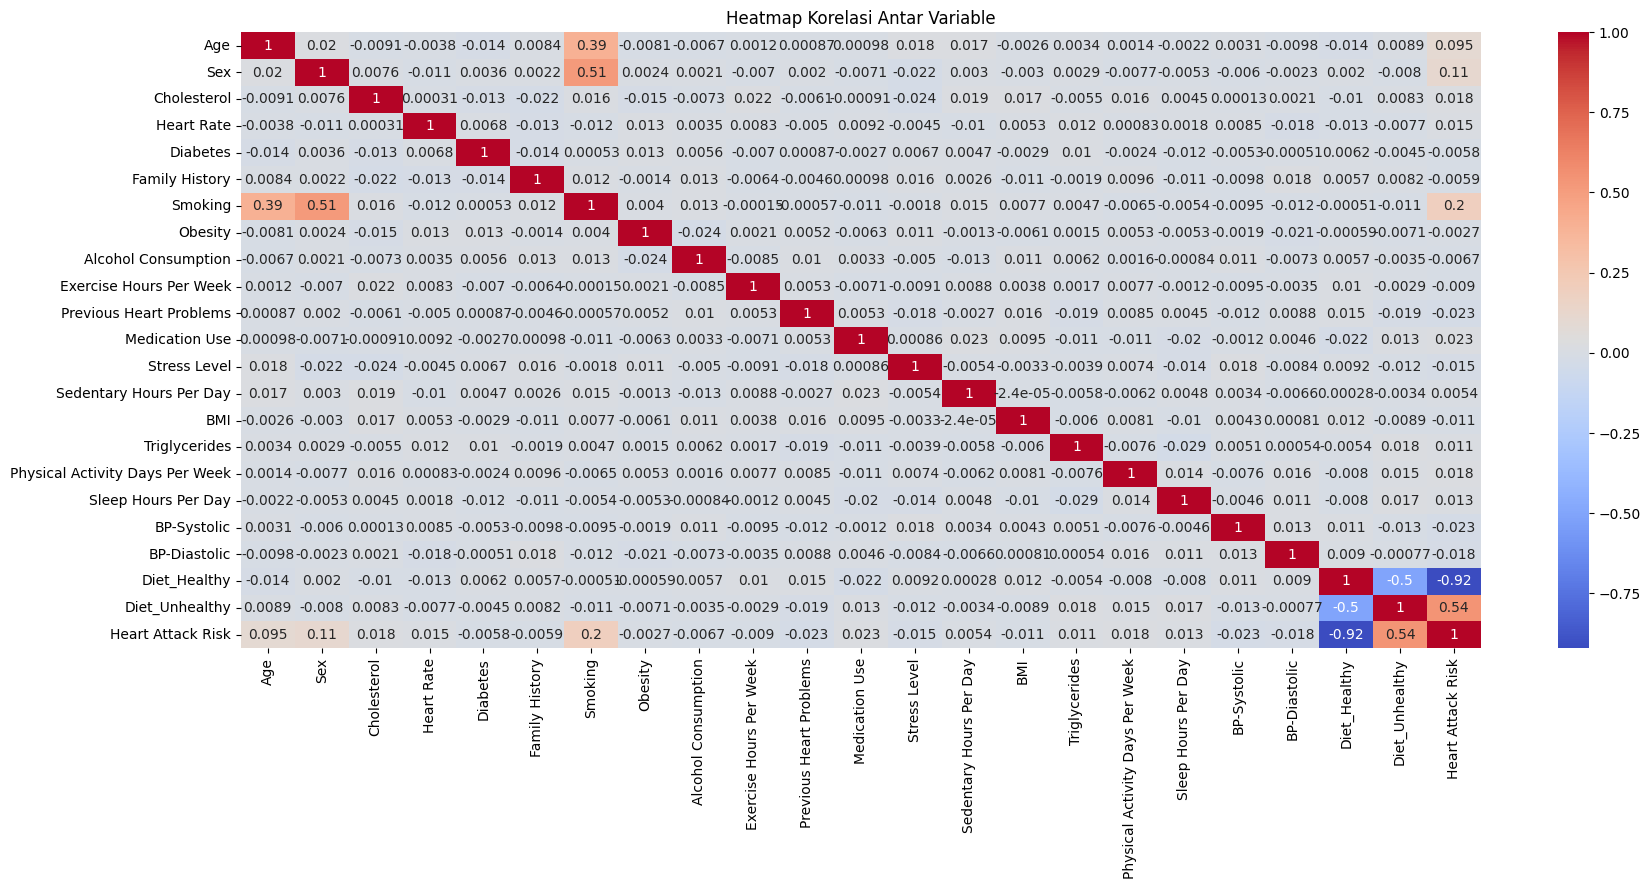

In [ ]:
corr = df_processed.corr()

plt.figure(figsize = (20, 8))
sns.heatmap(corr, annot = True, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Variable')
plt.show()

In [ ]:
X = df_processed.drop(columns=['Heart Attack Risk'])
y = df_processed['Heart Attack Risk']

In [ ]:
X = X.reset_index(drop = True) # untuk mengurutkan kembali indeksnya
y = y.reset_index(drop = True)

In [ ]:
X.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy
0,67,1,208,72,0,0,1,0,0,4.168189,0,0,9,6.615001,31.251233,286,0,6,158,88,0,0
1,21,1,389,98,1,1,1,1,1,1.813242,1,0,1,4.963459,27.194973,235,1,7,165,93,0,1
2,21,0,324,72,1,0,0,0,0,2.078353,1,1,9,9.463426,28.176571,587,4,4,174,99,1,0
3,84,1,383,73,1,1,1,0,1,9.828130,1,0,9,7.648981,36.464704,378,3,4,163,100,0,0
4,66,1,318,93,1,1,1,1,0,5.804299,1,0,6,1.514821,21.809144,231,1,5,91,88,0,1


In [ ]:
y.shape

(8763,)

## Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state_value, stratify=y)

In [ ]:
X_train

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,BP-Systolic,BP-Diastolic,Diet_Healthy,Diet_Unhealthy
2085,85,1,377,53,1,0,1,0,1,17.858777,1,1,1,5.698774,18.697314,493,4,7,104,88,0,0
7133,63,0,254,101,1,1,1,1,0,5.548696,1,1,10,7.534741,34.013819,82,3,9,158,105,0,1
1672,57,0,194,94,0,1,1,1,1,0.159661,0,1,3,11.961853,23.074056,421,2,8,138,69,0,0
7152,68,1,234,89,0,0,1,0,0,8.533685,0,1,6,9.158951,33.049796,91,3,10,97,76,1,0
5671,68,1,355,97,0,0,1,1,1,3.207349,0,1,1,1.791013,26.132549,521,5,9,123,77,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8412,72,1,380,90,0,0,1,0,0,6.900377,0,0,2,9.023553,19.456495,418,2,5,144,92,1,0
8153,25,1,192,68,0,0,1,1,1,10.270248,1,1,8,2.095368,21.276795,382,3,8,140,95,1,0
3065,35,1,340,64,0,0,1,1,1,17.107400,1,0,2,10.770754,30.663882,149,0,5,135,74,1,0
2339,82,1,281,104,1,0,1,1,1,17.250313,1,0,9,0.175281,18.499234,274,1,6,130,66,0,1


## Model Selection

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ]),

    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(
            random_state=random_state_value,
            n_estimators=100,
            min_samples_leaf=1,
            max_features='sqrt',
            ))
    ]),

    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(
            random_state=random_state_value,
            ccp_alpha=0.001
            ))
    ]),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            probability=True,
            random_state=random_state_value,
            C=1.0,
            gamma='scale',
            kernel='rbf',
            ))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),

    'XGBoost': Pipeline([
        ('clf', XGBClassifier(
            eval_metric='logloss',
            random_state=random_state_value,
            n_estimators=100,
        ))
    ])
}

In [ ]:
# Training dan evaluasi
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except Exception:
        roc = None

    print(f"--- {name} ---")
    print(cr)
    print('Accuracy:', acc)
    if roc is not None:
        print('ROC AUC:', roc)
    print('Confusion Matrix:\n', cm)
    print('\n')

    results.append({'name': name, 'model': model, 'accuracy': acc, 'roc_auc': roc})

# Ringkasan
summary_df = pd.DataFrame(results)[['name','accuracy','roc_auc']].sort_values(by='accuracy', ascending=False).reset_index(drop=True)
print('Ringkasan performa:')
display(summary_df)

# Simpan model terbaik (berdasarkan accuracy)
best = max(results, key=lambda x: x['accuracy'])
print('Best model:', best['name'], 'accuracy:', best['accuracy'])
# pickle.dump(best['model'], open('model_best.pkl', 'wb'))

--- LogisticRegression ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       658
           1       0.99      1.00      1.00      1095

    accuracy                           1.00      1753
   macro avg       1.00      0.99      1.00      1753
weighted avg       1.00      1.00      1.00      1753

Accuracy: 0.995436394751854
ROC AUC: 0.9999597507321203
Confusion Matrix:
 [[ 650    8]
 [   0 1095]]


--- RandomForest ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       658
           1       0.99      1.00      1.00      1095

    accuracy                           0.99      1753
   macro avg       1.00      0.99      0.99      1753
weighted avg       0.99      0.99      0.99      1753

Accuracy: 0.9937250427837993
ROC AUC: 0.9985413110158082
Confusion Matrix:
 [[ 647   11]
 [   0 1095]]


--- DecisionTree ---
              precision    recall  f1-score   support

           0 

,name,accuracy,roc_auc
0,LogisticRegression,0.995436,0.999960
1,XGBoost,0.994295,0.999850
2,RandomForest,0.993725,0.998541
3,DecisionTree,0.993725,0.992160
4,SVM,0.993725,0.999564
5,KNN,0.988591,0.995152


Best model: LogisticRegression accuracy: 0.995436394751854


In [ ]:
for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Probabilities
    y_train_prob = model.predict_proba(X_train)[:,1]
    y_test_prob = model.predict_proba(X_test)[:,1]

    # ROC AUC
    roc_train = roc_auc_score(y_train, y_train_prob)
    roc_test = roc_auc_score(y_test, y_test_prob)

    print(f"{name}")
    print(f"ROC-AUC Train: {roc_train:.4f}")
    print(f"ROC-AUC Test : {roc_test:.4f}")
    print("-"*30)

LogisticRegression
ROC-AUC Train: 1.0000
ROC-AUC Test : 1.0000
------------------------------
RandomForest
ROC-AUC Train: 1.0000
ROC-AUC Test : 0.9985
------------------------------
DecisionTree
ROC-AUC Train: 0.9943
ROC-AUC Test : 0.9922
------------------------------
SVM
ROC-AUC Train: 1.0000
ROC-AUC Test : 0.9996
------------------------------
KNN
ROC-AUC Train: 0.9995
ROC-AUC Test : 0.9952
------------------------------
XGBoost
ROC-AUC Train: 1.0000
ROC-AUC Test : 0.9999
------------------------------


## Handling Imbalance Data (SMOTE)

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_curve, roc_auc_score

models_smote = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', LogisticRegression(max_iter=1000))
    ]),

    'Random Forest': Pipeline([
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', RandomForestClassifier(
            random_state=random_state_value,
            n_estimators=100,
            min_samples_leaf=1,
            max_features='sqrt',
        ))
    ]),

    'Decision Tree': Pipeline([
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', DecisionTreeClassifier(
            random_state=random_state_value,
            ccp_alpha=0.001
        ))
    ]),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', SVC(
            probability=True,
            random_state=random_state_value,
            C=1.0,
            gamma='scale',
            kernel='rbf',
        ))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),

    'XGBoost': Pipeline([
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', XGBClassifier(
            eval_metric='logloss',
            random_state=random_state_value,
            n_estimators=100,
        ))
    ])
}

In [ ]:
def smote_cross_validate_models(X, y, model_dict):

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state_value)

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }

    results = []

    for name, model in model_dict.items():

        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )

        results.append({
            "Model": name,
            "Accuracy": np.mean(scores["test_accuracy"]),
            "ROC_AUC_mean": np.mean(scores["test_roc_auc"]),
            "Recall_mean": np.mean(scores["test_recall"]),
            "ROC_AUC_train": np.mean(scores["train_roc_auc"]),
            "Overfit_gap": np.mean(scores["train_roc_auc"]) - np.mean(scores["test_roc_auc"])
        })

    return pd.DataFrame(results).sort_values(by="ROC_AUC_mean", ascending=False)

In [ ]:
my_cv = smote_cross_validate_models(X_train,y_train, models_smote)
my_cv

,Model,Accuracy,ROC_AUC_mean,Recall_mean,ROC_AUC_train,Overfit_gap
0,Logistic Regression,0.996291,0.999984,1.000000,0.999993,0.000009
3,SVM,0.995435,0.999887,1.000000,1.000000,0.000113
5,XGBoost,0.994009,0.999790,0.997259,1.000000,0.000210
1,Random Forest,0.995435,0.999484,1.000000,1.000000,0.000516
2,Decision Tree,0.995292,0.996854,0.999543,0.996847,-0.000008
4,KNN,0.971041,0.995840,0.960951,0.999283,0.003443


In [ ]:
best_model_name = my_cv.iloc[0]["Model"]
best_model = models_smote[best_model_name]

smote = best_model.named_steps['smote']

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(X_train_resampled.shape)
print(y_train_resampled.value_counts())

(8758, 22)
Heart Attack Risk
1    4379
0    4379
Name: count, dtype: int64


In [ ]:
my_cv_resampled = smote_cross_validate_models(X_train_resampled, y_train_resampled, models_smote)
my_cv_resampled

,Model,Accuracy,ROC_AUC_mean,Recall_mean,ROC_AUC_train,Overfit_gap
0,Logistic Regression,0.994862,0.999905,0.999315,0.999935,0.000030
5,XGBoost,0.995090,0.999798,0.997717,1.000000,0.000202
1,Random Forest,0.994177,0.999727,1.000000,1.000000,0.000273
3,SVM,0.992578,0.999725,1.000000,0.999998,0.000273
4,KNN,0.974880,0.996858,0.958210,0.999295,0.002437
2,Decision Tree,0.992235,0.993692,0.999315,0.994139,0.000447


##  Model Tuning

### ROC AUC

In [ ]:
models_smote

{'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                 ('model', LogisticRegression(max_iter=1000))]),
 'Random Forest': Pipeline(steps=[('smote', SMOTE(random_state=42)),
                 ('model', RandomForestClassifier(random_state=42))]),
 'Decision Tree': Pipeline(steps=[('smote', SMOTE(random_state=42)),
                 ('model',
                  DecisionTreeClassifier(ccp_alpha=0.001, random_state=42))]),
 'SVM': Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                 ('model', SVC(probability=True, random_state=42))]),
 'KNN': Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                 ('model', KNeighborsClassifier())]),
 'XGBoost': Pipeline(steps=[('smote', SMOTE(random_state=42)),
                 ('model',
                  XGBClassifier(base_score=None, booster=None, callbacks=None,
                                colsample_by

In [ ]:
# Hyperparameter tuning ROC AUC

# Define hyperparameter grids for each model
param_grids = {
    'Logistic Regression': {
        'model__C': [0.1, 1, 10],
        'model__solver': ['lbfgs', 'liblinear', 'saga'],
        'model__penalty': ['l1', 'l2', 'elasticnet']
    },
    'Random Forest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [5, 10, 20, None],
        'model__min_samples_split': [2, 5],
        'model__max_features': ['sqrt', 'log2', None]
    },
    'Decision Tree': {
        'model__criterion': ['gini', 'entropy', 'log_loss'],
        'model__max_depth': [None, 5, 10, 15, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': [None, 'sqrt', 'log2'],
        'model__ccp_alpha': [0.0, 0.0001, 0.001, 0.01]
    },
    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto']
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9],
        'model__weights': ['uniform', 'distance']
    },
    'XGBoost': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.8, 1.0]
    }
}


# GridSearchCV for each model
best_models = {}
best_model_scores = {}
for name, model in models_smote.items():
    print(f"\n🔍 Tuning {name}...")
    grid_search = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    best_model_scores[name] = grid_search.best_score_
    print(f"✅ Best params: {grid_search.best_params_}")
    print(f"   Best CV score: {grid_search.best_score_:.4f}")


🔍 Tuning Logistic Regression...
✅ Best params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
   Best CV score: 1.0000

🔍 Tuning Random Forest...
✅ Best params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 200}
   Best CV score: 0.9997

🔍 Tuning Decision Tree...
✅ Best params: {'model__ccp_alpha': 0.001, 'model__criterion': 'entropy', 'model__max_depth': 5, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
   Best CV score: 0.9991

🔍 Tuning SVM...
✅ Best params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
   Best CV score: 1.0000

🔍 Tuning KNN...
✅ Best params: {'model__n_neighbors': 9, 'model__weights': 'distance'}
   Best CV score: 0.9981

🔍 Tuning XGBoost...
✅ Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
   Best CV score: 0.9999


In [ ]:
models_smote_tuned = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', LogisticRegression(random_state=random_state_value,
                                     C=10, penalty='l1', solver='liblinear'))
    ]),

    "Random Forest": Pipeline([
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', RandomForestClassifier(random_state=random_state_value,
                                         max_depth=10, max_features='sqrt', min_samples_split=2, n_estimators=200))
    ]),
    'Decision Tree': Pipeline([
            ('smote', SMOTE(random_state=random_state_value)),
            ('model', DecisionTreeClassifier(
                random_state=random_state_value,
                ccp_alpha=0.001, criterion='entropy',max_depth=5,max_features=None, min_samples_leaf=1,min_samples_split=2
            ))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', SVC(probability=True, random_state=random_state_value,
                      C=10, gamma='scale', kernel='linear'))
    ]),

    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=random_state_value)),
        ('model', KNeighborsClassifier(n_neighbors=9, weights='distance'))
    ]),

    "XGBoost": Pipeline([
    ('smote', SMOTE(random_state=random_state_value)),
    ('model', XGBClassifier(
        random_state=random_state_value,
        learning_rate=0.1,
        max_depth=7,
        n_estimators=200,
        subsample=0.8
    ))
])
}

In [ ]:
results = []
for name, model in models_smote_tuned.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except Exception:
        roc = None

    print(f"--- {name} ---")
    print(cr)
    print('Accuracy:', acc)
    print('Recall:', recall)
    if roc is not None:
        print('ROC AUC:', roc)
    print('Confusion Matrix:\n', cm)
    print('\n')

    # simpan model individual
    # pickle.dump(model, open(f'tuned_rocauc_model_{name}.pkl', 'wb'))

    results.append({'name': name, 'model': model, 'accuracy': acc, 'roc_auc': roc, 'recall': recall})

# Ringkasan
summary_df = pd.DataFrame(results)[['name','accuracy','roc_auc', 'recall']].sort_values(by='roc_auc', ascending=False).reset_index(drop=True)
print('Ringkasan performa:')
display(summary_df)

# Simpan model terbaik (berdasarkan roc_auc)
best = max(results, key=lambda x: x['roc_auc'])
print('Best model:', best['name'], 'roc_auc:', best['roc_auc'])
print(f"ROC_train - ROC_test: {best_model_scores[best['name']] * 100 - best['roc_auc'] * 100} %")


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       658
           1       1.00      1.00      1.00      1095

    accuracy                           1.00      1753
   macro avg       1.00      1.00      1.00      1753
weighted avg       1.00      1.00      1.00      1753

Accuracy: 0.9982886480319453
Recall: 1.0
ROC AUC: 1.0
Confusion Matrix:
 [[ 655    3]
 [   0 1095]]


--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       658
           1       0.99      1.00      1.00      1095

    accuracy                           0.99      1753
   macro avg       1.00      0.99      0.99      1753
weighted avg       0.99      0.99      0.99      1753

Accuracy: 0.9937250427837993
Recall: 1.0
ROC AUC: 0.9994836990465088
Confusion Matrix:
 [[ 647   11]
 [   0 1095]]


--- Decision Tree ---
              precision    recall  f1-score   support



,name,accuracy,roc_auc,recall
0,Logistic Regression,0.998289,1.000000,1.000000
1,SVM,0.996577,0.999979,0.998174
2,XGBoost,0.993155,0.999696,0.997260
3,Random Forest,0.993725,0.999484,1.000000
4,Decision Tree,0.993725,0.998496,1.000000
5,KNN,0.981175,0.996887,0.976256


Best model: Logistic Regression roc_auc: 1.0
ROC_train - ROC_test: -0.0012147826119530691 %


## Check Overfitting/Underfitting

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        random_state=42))])
Train AUC : 1.0000
Test AUC  : 0.9995
AUC Gap   : 0.0005
Model generalizes well (tidak ada overfitting signifikan).


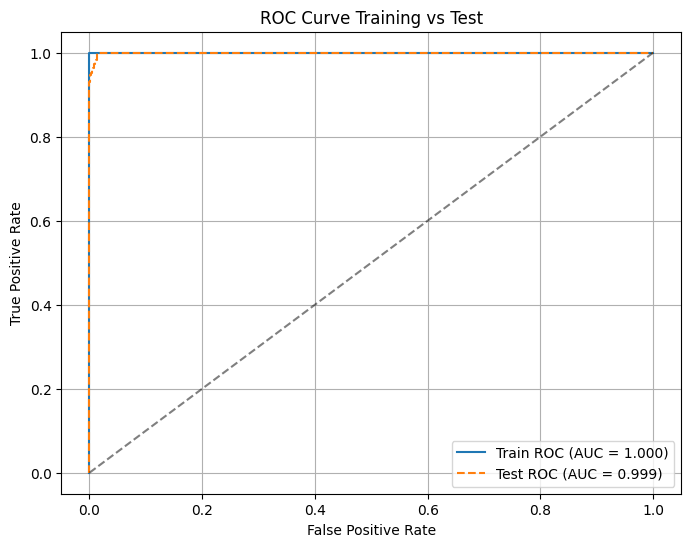

In [ ]:
# gunakan model terbaik yang sudah tersimpan di variabel `best`
selected_model_name = "Random Forest"
model = models_smote_tuned[selected_model_name]
print(model)
model.fit(X_train, y_train)
# probabilitas prediksi
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba  = model.predict_proba(X_test)[:, 1]

# hitung ROC
from sklearn.metrics import roc_curve, auc

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_test_proba)

roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test  = auc(fpr_test,  tpr_test)

# cek gap
gap = roc_auc_train - roc_auc_test

print(f"Train AUC : {roc_auc_train:.4f}")
print(f"Test AUC  : {roc_auc_test:.4f}")
print(f"AUC Gap   : {gap:.4f}")

# diagnosis
if roc_auc_train < 0.5 and roc_auc_test < 0.5:
    print("Model kemungkinan UNDERFITTING (tidak menangkap pola data).")
elif gap > 0.10:
    print("Model kemungkinan OVERFITTING (terlalu belajar dari data training).")
elif gap > 0.05:
    print("Model sedikit overfitting, masih bisa diperbaiki.")
else:
    print("Model generalizes well (tidak ada overfitting signifikan).")

# plot ROC
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {roc_auc_train:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {roc_auc_test:.3f})', linestyle='--')
plt.plot([0,1],[0,1],'k--', alpha=0.5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Training vs Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Check data leakage

In [ ]:
importances = model.named_steps['model'].feature_importances_
# create dataframe
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# sort descending
feature_importance = feature_importance.sort_values(by="importance", ascending=False)

# show top 10
top10 = feature_importance.head(10)
print(top10)

                    feature  importance
20             Diet_Healthy    0.618254
21           Diet_Unhealthy    0.198310
6                   Smoking    0.052327
1                       Sex    0.033551
0                       Age    0.023451
15            Triglycerides    0.006544
13  Sedentary Hours Per Day    0.006393
9   Exercise Hours Per Week    0.006382
14                      BMI    0.006145
2               Cholesterol    0.005734


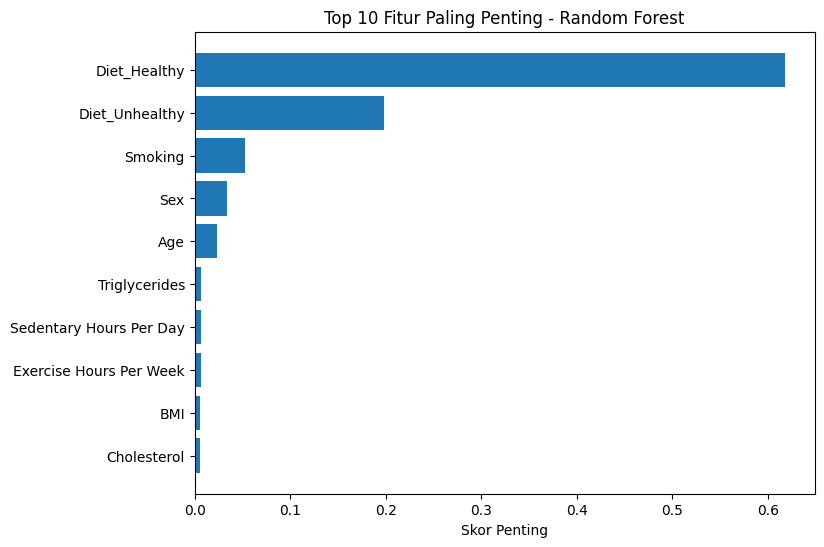

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()

plt.xlabel("Skor Penting")
plt.title("Top 10 Fitur Paling Penting - "+selected_model_name)
plt.show()

## Save model

In [ ]:
pickle.dump(model, open('model_'+selected_model_name+'.pkl', 'wb'))